In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import optim
from torch.utils.data import Dataset, DataLoader
from torch.nn import functional as F
from torch.optim import lr_scheduler
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from apafib import load_MITBIH
import sys
from pytorch_generative import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


In [52]:
data = load_MITBIH()
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

X_normal = X[y == 'Normal'] 

padding = np.zeros((X_normal.shape[0], 2))
X_padded = np.hstack((X_normal, padding))

print(f"Shape original: {X_normal.shape}, Shape con padding: {X_padded.shape}")

X_discretization, X_autoreg = train_test_split(X_padded, test_size=0.66, random_state=42)

Shape original: (7263, 94), Shape con padding: (7263, 96)


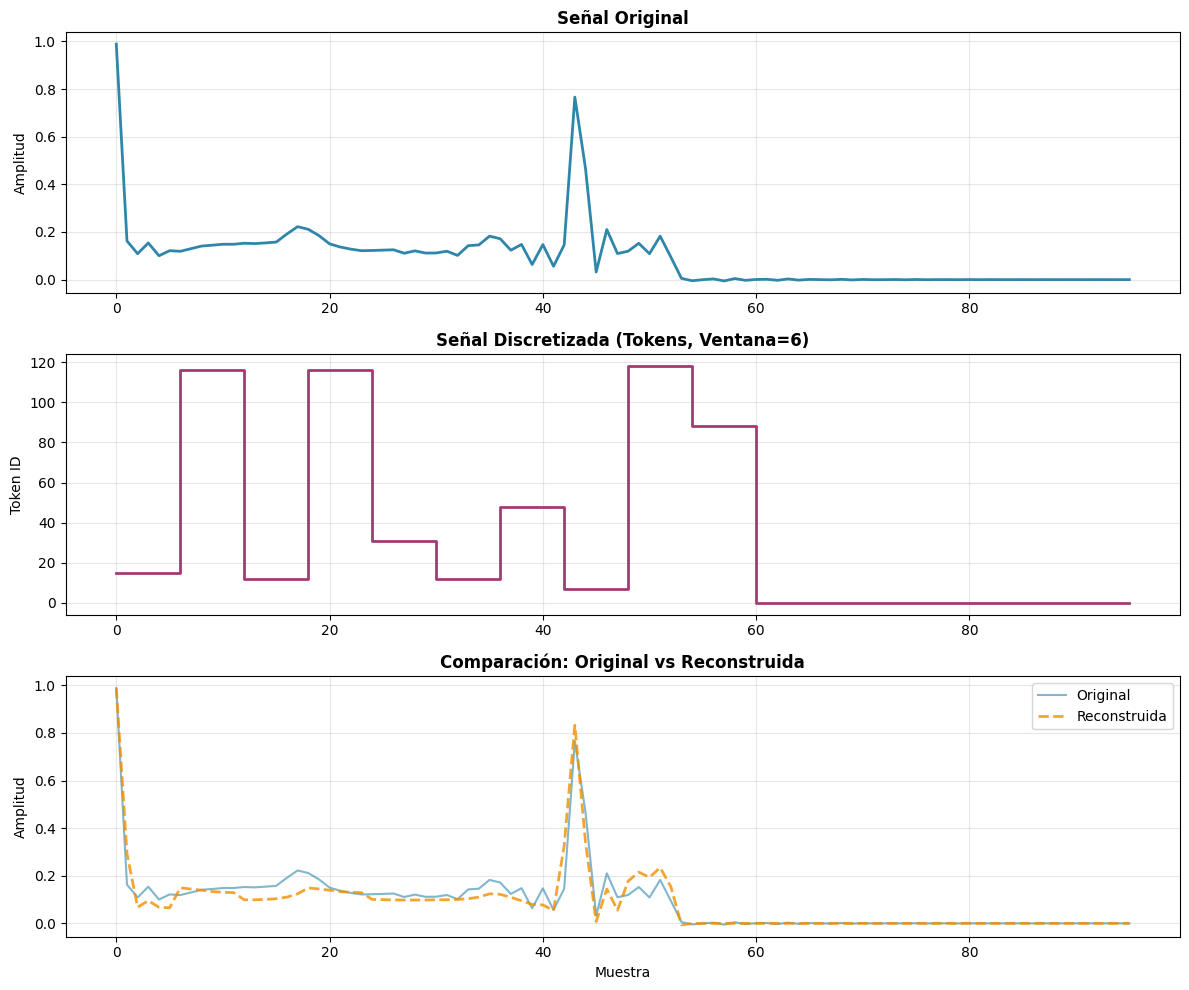

In [53]:
WINDOW_SIZE = 6
VOCAB_SIZE = 128

X_windows = X_discretization.reshape(-1, WINDOW_SIZE)

gmm = GaussianMixture(n_components=VOCAB_SIZE, covariance_type='full', random_state=42)
gmm.fit(X_windows)


def discretize_signals(signals, window_size, model):
    n_samples, length = signals.shape
    windows = signals.reshape(-1, window_size)
    tokens = model.predict(windows)
    return tokens.reshape(n_samples, -1)

def reconstruct_signals(tokens, window_size, model):
    centroids = model.means_
    n_samples, n_tokens = tokens.shape
    reconstructed = np.zeros((n_samples, n_tokens * window_size))
    
    for i in range(n_samples):
        seq = centroids[tokens[i]]
        reconstructed[i] = seq.flatten()
        
    return reconstructed

idx = 0
sample_signal = X_discretization[idx:idx+1]
sample_tokens = discretize_signals(sample_signal, WINDOW_SIZE, gmm)
sample_reconstructed = reconstruct_signals(sample_tokens, WINDOW_SIZE, gmm)

sample_discretized = np.repeat(sample_tokens[0], WINDOW_SIZE)

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

axes[0].plot(sample_signal[0], color='#2E86AB', linewidth=2)
axes[0].set_title('Señal Original', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Amplitud')
axes[0].grid(True, alpha=0.3)

axes[1].step(range(len(sample_discretized)), sample_discretized, where='post', color='#A23B72', linewidth=2)
axes[1].set_title(f'Señal Discretizada (Tokens, Ventana={WINDOW_SIZE})', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Token ID')
axes[1].grid(True, alpha=0.3)

axes[2].plot(sample_signal[0], label='Original', alpha=0.6, color='#2E86AB', linewidth=1.5)
axes[2].plot(sample_reconstructed[0], label='Reconstruida', alpha=0.8, color='#F18F01', linewidth=2, linestyle='--')
axes[2].set_title('Comparación: Original vs Reconstruida', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Amplitud')
axes[2].set_xlabel('Muestra')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [54]:
X_autoreg_tokens = discretize_signals(X_autoreg, WINDOW_SIZE, gmm)

X_train, X_temp = train_test_split(X_autoreg_tokens, test_size=0.5, random_state=42)
X_val, X_test = train_test_split(X_temp, test_size=0.5, random_state=42)

class ECGTokenDataset(Dataset):
    def __init__(self, token_data, vocab_size):
        self.data = token_data
        self.vocab_size = vocab_size

    def __getitem__(self, index):
        tokens = torch.tensor(self.data[index], dtype=torch.long)
        x_onehot = F.one_hot(tokens, num_classes=self.vocab_size).float()
        return x_onehot.view(-1) 

    def __len__(self):
        return len(self.data)

train_ds = ECGTokenDataset(X_train, VOCAB_SIZE)
val_ds = ECGTokenDataset(X_val, VOCAB_SIZE)
test_ds = ECGTokenDataset(X_test, VOCAB_SIZE)

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=64, shuffle=False)

T-Loss: 30.6676 V-Loss: 35.3570: 100%|██████████| 100/100 [01:11<00:00,  1.40it/s] 



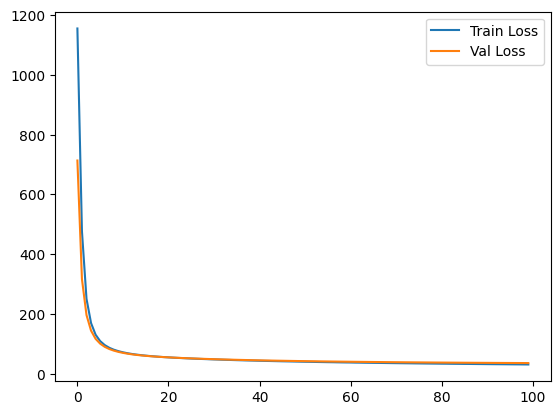

In [55]:
seq_len = X_padded.shape[1] // WINDOW_SIZE
input_dim = seq_len * VOCAB_SIZE

HIDDEN_DIMS = [256]
LR = 1e-3
EPOCHS = 100

made_model = models.MADE(input_dim=input_dim, hidden_dims=HIDDEN_DIMS, n_masks=1)
made_model.to(device)

optimizer = optim.Adam(made_model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = lr_scheduler.MultiplicativeLR(optimizer, lr_lambda=lambda _: 0.99)

def loss_fn(inputs, preds):
    loss = F.binary_cross_entropy_with_logits(preds, inputs, reduction='none')
    return loss.sum(dim=1).mean()

def train_validate_loop(model, optimizer, scheduler, loss_fn, train_loader, val_loader, epochs):
    train_losses = []
    val_losses = []
    
    pbar = tqdm(range(epochs))
    for epoch in pbar:
        model.train()
        running_loss = 0.0
        for i, data in enumerate(train_loader):
            inputs = data.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(inputs, outputs)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for i, data in enumerate(val_loader):
                inputs = data.to(device)
                outputs = model(inputs)
                loss = loss_fn(inputs, outputs)
                running_val_loss += loss.item()
        
        avg_val_loss = running_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        if scheduler:
            scheduler.step()
            
        pbar.set_description(f'T-Loss: {avg_train_loss:.4f} V-Loss: {avg_val_loss:.4f}')

    return train_losses, val_losses

train_hist, val_hist = train_validate_loop(made_model, optimizer, scheduler, loss_fn, train_dl, val_dl, EPOCHS)

plt.plot(train_hist, label='Train Loss')
plt.plot(val_hist, label='Val Loss')
plt.legend()
plt.show()

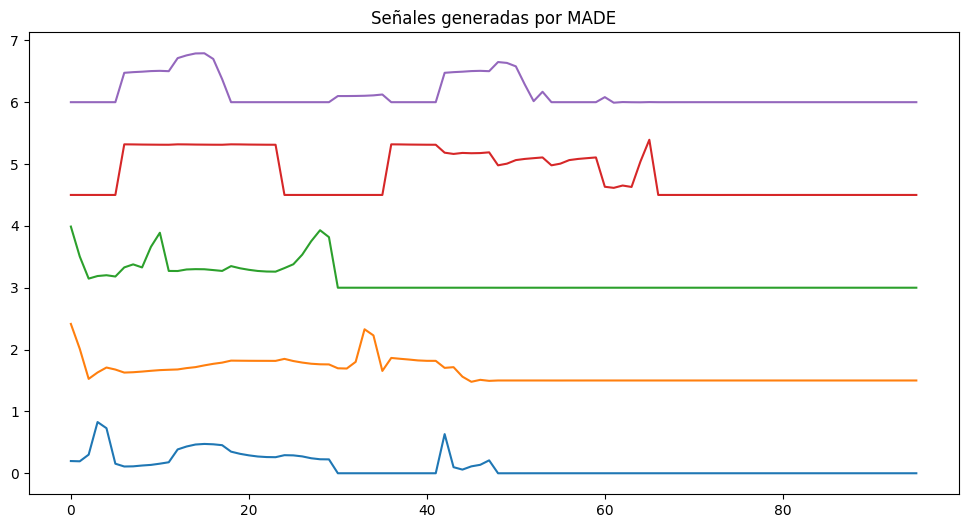

NLL promedio en Train: 30.5353
NLL promedio en Val: 35.3319
NLL promedio en Test: 35.6803


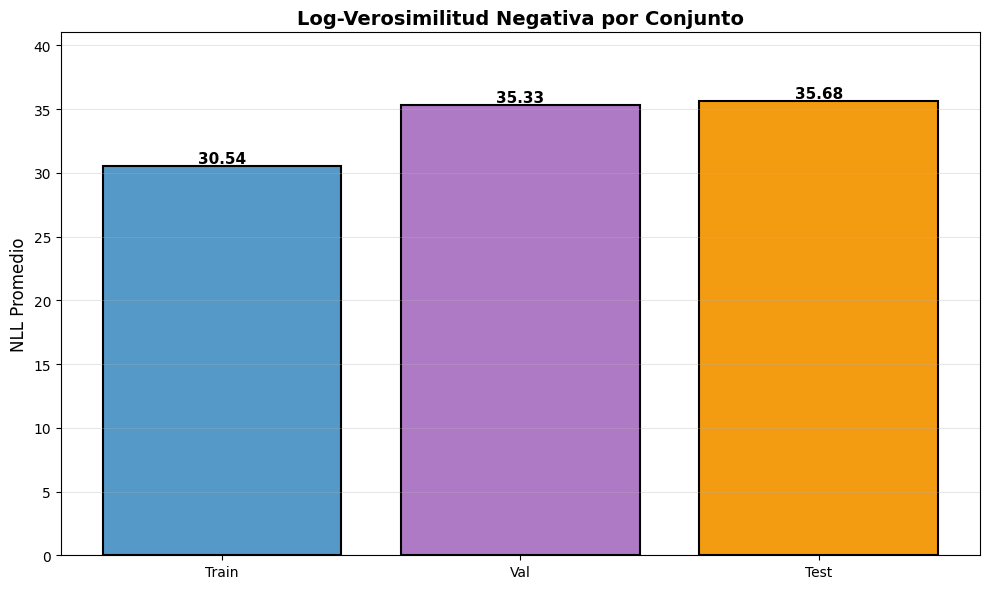

NLL promedio en Anomalías: 54.4067
Diferencia: 18.7264


In [ ]:
def generate_samples(model, n_samples, seq_len, vocab_size, window_size, gmm_model):
    model.eval()
    input_dim = seq_len * vocab_size
    conditioned_on = (torch.ones((n_samples, input_dim)) * -1).to(device)
    
    with torch.no_grad():
        samples_flat = model.sample(n_samples, conditioned_on=conditioned_on)
    
    samples_reshaped = samples_flat.view(n_samples, seq_len, vocab_size)
    tokens = torch.argmax(samples_reshaped, dim=2).cpu().numpy()
    signals = reconstruct_signals(tokens, window_size, gmm_model)
    return signals

gen_signals = generate_samples(made_model, 5, seq_len, VOCAB_SIZE, WINDOW_SIZE, gmm)
plt.figure(figsize=(12, 6))
for i in range(5):
    plt.plot(gen_signals[i] + i*1.5, label=f'Generada {i}')
plt.title("Señales generadas por MADE")
plt.show()

def calculate_nll(model, dataset):
    loader = DataLoader(dataset, batch_size=32, shuffle=False)
    model.eval()
    total_nll = 0
    with torch.no_grad():
        for inputs in loader:
            inputs = inputs.to(device)
            logits = model(inputs)
            probs = torch.sigmoid(logits)
            epsilon = 1e-10
            batch_nll = - (inputs * torch.log(probs + epsilon) + (1 - inputs) * torch.log(1 - probs + epsilon)).sum(dim=1)
            total_nll += batch_nll.sum().item()
            
    return total_nll / len(dataset)

nll_train = calculate_nll(made_model, train_ds)
nll_val = calculate_nll(made_model, val_ds)
nll_test = calculate_nll(made_model, test_ds)

print(f"NLL promedio en Train: {nll_train:.4f}")
print(f"NLL promedio en Val: {nll_val:.4f}")
print(f"NLL promedio en Test: {nll_test:.4f}")

nll_splits = {'Train': nll_train, 'Val': nll_val, 'Test': nll_test}
labels_splits = list(nll_splits.keys())
values_splits = list(nll_splits.values())
colors_splits = ['#5499C7', '#AF7AC5', '#F39C12']

plt.figure(figsize=(10, 6))
bars = plt.bar(labels_splits, values_splits, color=colors_splits, edgecolor='black', linewidth=1.5)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.title('Log-Verosimilitud Negativa por Conjunto', fontsize=14, fontweight='bold')
plt.ylabel('NLL Promedio', fontsize=12)
plt.grid(axis='y', linestyle='-', alpha=0.3)
plt.ylim(0, max(values_splits) * 1.15)
plt.tight_layout()
plt.show()

X_anom = X[y != 'Normal']
if len(X_anom) > 0:
    X_anom_sample = X_anom[:200]
    X_anom_padded = np.hstack((X_anom_sample, np.zeros((X_anom_sample.shape[0], 2))))
    X_anom_tokens = discretize_signals(X_anom_padded, WINDOW_SIZE, gmm)
    anom_ds = ECGTokenDataset(X_anom_tokens, VOCAB_SIZE)
    nll_anomaly = calculate_nll(made_model, anom_ds)
    print(f"NLL promedio en Anomalías: {nll_anomaly:.4f}")
    print(f"Diferencia: {nll_anomaly - nll_test:.4f}")

print("\n--- Comparación Generadas vs Reales ---")
gen_samples_large = generate_samples(made_model, 100, seq_len, VOCAB_SIZE, WINDOW_SIZE, gmm)
real_samples = X_test[:100]

from scipy.spatial.distance import euclidean
from scipy.stats import pearsonr

euclidean_dists = [euclidean(gen_samples_large[i], real_samples[i]) for i in range(100)]
correlations = [pearsonr(gen_samples_large[i], real_samples[i])[0] for i in range(100)]

print(f"Distancia Euclidiana promedio: {np.mean(euclidean_dists):.4f} ± {np.std(euclidean_dists):.4f}")
print(f"Correlación de Pearson promedio: {np.mean(correlations):.4f} ± {np.std(correlations):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(euclidean_dists, bins=20, color='#5499C7', edgecolor='black', alpha=0.7)
axes[0].set_title('Distancia Euclidiana (Generadas vs Reales)', fontweight='bold')
axes[0].set_xlabel('Distancia')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(True, alpha=0.3)

axes[1].hist(correlations, bins=20, color='#F39C12', edgecolor='black', alpha=0.7)
axes[1].set_title('Correlación de Pearson (Generadas vs Reales)', fontweight='bold')
axes[1].set_xlabel('Correlación')
axes[1].set_ylabel('Frecuencia')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [57]:
#fa una mica de overfitting pero meh

Calculando NLL para cada tipo de anomalía...
 - ArrS: 54.0087
 - ArrV: 53.1744
 - ArrF: 34.3213
 - ArrV: 53.1744
 - ArrF: 34.3213
 - ArrQ: 58.0106
 - ArrQ: 58.0106


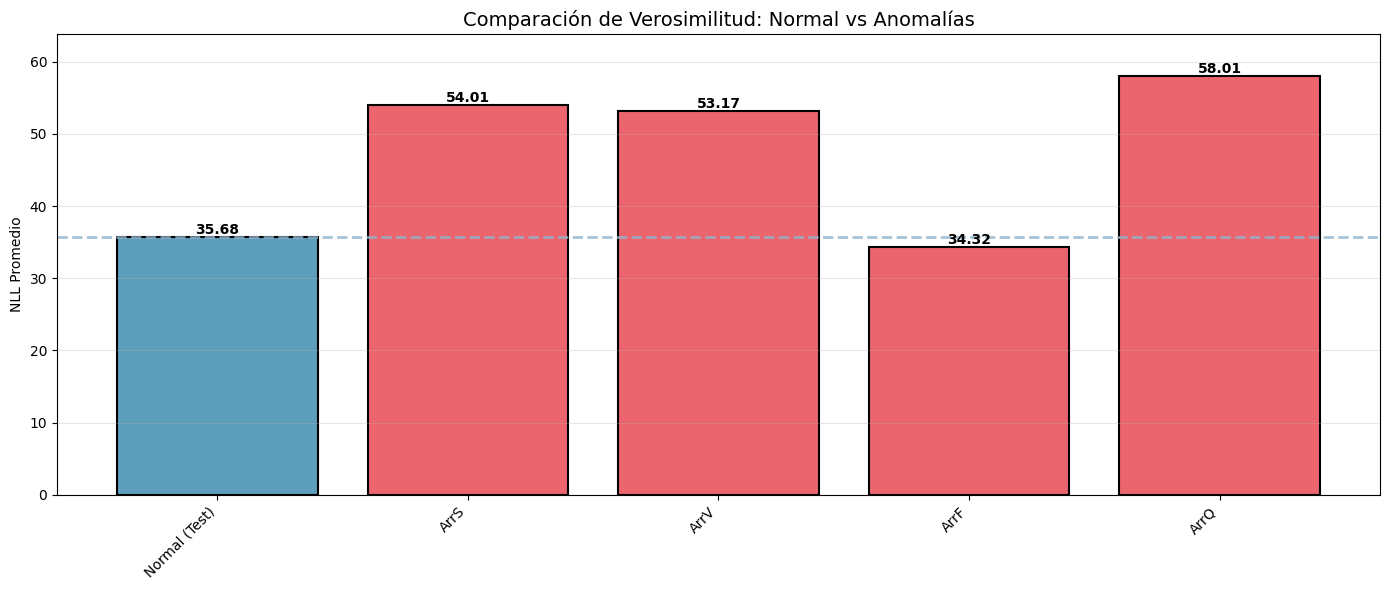

In [58]:
import matplotlib.pyplot as plt

class_map = {1: 'ArrS', 2: 'ArrV', 3: 'ArrF', 4: 'ArrQ'}
nll_results = {'Normal (Test)': nll_test}

print("Calculando NLL para cada tipo de anomalía...")

for class_id, class_name in class_map.items():
    X_class = X[y == class_name]
    
    if len(X_class) == 0:
        continue
        
    limit = min(len(X_class), 500)
    X_class_sample = X_class[:limit]
    
    padding = np.zeros((X_class_sample.shape[0], 2))
    X_class_padded = np.hstack((X_class_sample, padding))
    X_class_tokens = discretize_signals(X_class_padded, WINDOW_SIZE, gmm)
    ds_class = ECGTokenDataset(X_class_tokens, VOCAB_SIZE)
    nll_val = calculate_nll(made_model, ds_class)
    nll_results[class_name] = nll_val
    print(f" - {class_name}: {nll_val:.4f}")

labels = list(nll_results.keys())
values = list(nll_results.values())
colors = ['#5c9ebc' if 'Normal' in label else '#eb656e' for label in labels]

plt.figure(figsize=(14, 6))
bars = plt.bar(labels, values, color=colors, edgecolor='black', linewidth=1.5)
plt.axhline(y=nll_results['Normal (Test)'], color='#90b4ce', linestyle='--', linewidth=2, alpha=0.8)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}',
             ha='center', va='bottom', fontweight='bold')

plt.title('Comparación de Verosimilitud: Normal vs Anomalías', fontsize=14)
plt.ylabel('NLL Promedio')
plt.grid(axis='y', linestyle='-', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(values) * 1.1)
plt.tight_layout()
plt.show()